### Input 데이터 불러오기 (훈련데이터 6만개)

In [1]:
import torch
from torchvision import datasets, transforms
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# MNIST 데이터셋을 로드합니다.
transform = transforms.Compose([transforms.ToTensor()])
mnist = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9.91M/9.91M [00:00<00:00, 39.5MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28.9k/28.9k [00:00<00:00, 1.27MB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1.65M/1.65M [00:00<00:00, 10.8MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4.54k/4.54k [00:00<00:00, 7.12MB/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



### 컬러 MNIST 데이터 생성하기

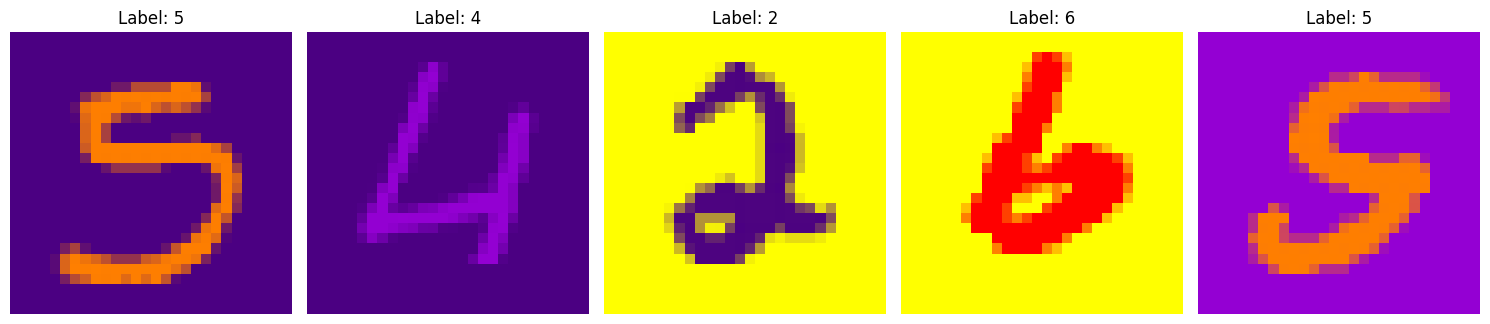

In [2]:
import numpy as np
import torch
from torchvision import datasets, transforms
from PIL import ImageOps
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

# 무지개 색상 팔레트를 정의합니다 (7가지 색상).
RAINBOW_COLORS = [
    (255, 0, 0),    # 빨강
    (255, 127, 0),  # 주황
    (255, 255, 0),  # 노랑
    (0, 255, 0),    # 초록
    (0, 0, 255),    # 파랑
    (75, 0, 130),   # 남색 (인디고)
    (148, 0, 211)   # 보라
]

RAINBOW_NAMES = [
    'RED',
    'ORANGE',
    'YELLOW',
    'GREEN',
    'BLUE',
    'INDIGO',
    'VIOLET'
]

def get_random_rainbow_color():
    """무지개 팔레트에서 임의의 색상을 선택합니다."""
    idx = np.random.randint(0, len(RAINBOW_COLORS))
    return RAINBOW_COLORS[idx], RAINBOW_NAMES[idx]

def colorize_digit(digit_image, fg_color, bg_color):
    """숫자 이미지에 전경(fg)과 배경(bg) 색상을 적용합니다."""
    digit = digit_image.convert('L')  # 이미지를 그레이스케일로 변환합니다.
    colored_digit = ImageOps.colorize(digit, black=bg_color, white=fg_color).convert('RGBA')
    return colored_digit

def overlay_digit_on_background(colored_digit):
    """투명도를 제거하고 일관된 배경 이미지를 생성합니다."""
    final_image = colored_digit.convert('RGB')  # 투명도를 제거합니다.
    return final_image

# 무작위성을 위해 시드를 설정합니다.
np.random.seed(42)

# MNIST 데이터셋을 로드합니다.
transform = transforms.Compose([transforms.ToTensor()])
mnist = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

class ColoredMNISTDataset(Dataset):
    def __init__(self, mnist_dataset):
        self.mnist_dataset = mnist_dataset
        self.colored_images = []
        self.labels = []
        self._create_colored_dataset()

    def _create_colored_dataset(self):
        for idx in range(len(self.mnist_dataset)):
            image, label = self.mnist_dataset[idx]
            pil_image = transforms.ToPILImage()(image)

            # 전경과 배경 색상을 무작위로 선택합니다.
            fg_color, fg_label = get_random_rainbow_color()
            bg_color, bg_label = get_random_rainbow_color()

            # 전경과 배경 색상이 같지 않도록 보장합니다.
            while bg_color == fg_color:
                bg_color, bg_label = get_random_rainbow_color()

            # 선택된 색상으로 숫자 이미지를 색칠합니다.
            colored_digit = colorize_digit(pil_image, fg_color, bg_color)
            final_image = overlay_digit_on_background(colored_digit)

            # 컬러화된 이미지를 리스트에 추가합니다.
            self.colored_images.append(final_image)
            self.labels.append(label)

    def __len__(self):
        return len(self.colored_images)

    def __getitem__(self, idx):
        image = self.colored_images[idx]
        label = self.labels[idx]
        image = transforms.ToTensor()(image)  # 이미지를 텐서로 변환합니다.
        return image, label

    def get_all_images(self):
        return self.colored_images, self.labels

# 컬러화된 MNIST 데이터셋을 생성합니다.
colored_mnist_dataset = ColoredMNISTDataset(mnist)
colored_mnist_loader = DataLoader(colored_mnist_dataset, batch_size=64, shuffle=True)

# 모든 컬러화된 이미지와 라벨을 가져옵니다.
all_images, all_labels = colored_mnist_dataset.get_all_images()

# 일부 배치를 시각적으로 확인합니다.
dataiter = iter(colored_mnist_loader)
images, labels = next(dataiter)

fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for i in range(5):
    axes[i].imshow(transforms.ToPILImage()(images[i]))
    axes[i].axis('off')
    axes[i].set_title(f'Label: {labels[i].item()}')
plt.tight_layout()
plt.show()


## Component1. 후경 분류기

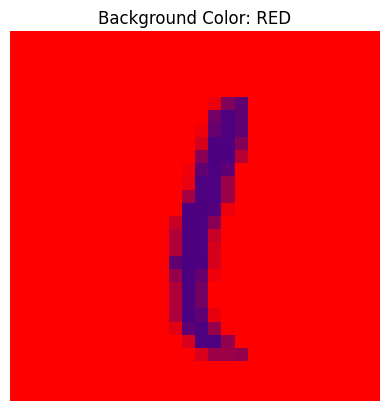

In [3]:
from collections import Counter
import numpy as np
import random

def extract_border_colors(image):
    """
    이미지를 받아 테두리 픽셀의 색상을 추출합니다.
    Args:
        image: RGB 모드의 PIL 이미지.
    Returns:
        border_colors: 테두리 픽셀 색상의 리스트.
    """
    image_np = np.array(image)  # (H, W, 3) 형태의 NumPy 배열로 변환
    height, width, _ = image_np.shape

    # 상단, 하단, 좌측, 우측 테두리 추출
    top_border = image_np[0, :, :]       # 상단 테두리
    bottom_border = image_np[-1, :, :]  # 하단 테두리
    left_border = image_np[:, 0, :]     # 좌측 테두리
    right_border = image_np[:, -1, :]   # 우측 테두리

    # 테두리 색상 결합
    border_colors = np.vstack([top_border, bottom_border, left_border, right_border])
    return [tuple(color) for color in border_colors]  # RGB 색상 튜플 리스트 반환

def most_frequent_color(border_colors):
    """
    테두리 색상 중 가장 빈도가 높은 색상을 반환합니다.
    Args:
        border_colors: 테두리 색상 리스트.
    Returns:
        가장 빈도가 높은 색상 (RGB 튜플).
    """
    counter = Counter(border_colors)
    most_common_color = counter.most_common(1)[0][0]
    return most_common_color

def get_color_name(color):
    """주어진 RGB 색상에 해당하는 이름을 반환합니다."""
    if color in RAINBOW_COLORS:
        idx = RAINBOW_COLORS.index(color)
        return RAINBOW_NAMES[idx]
    return "Unknown"  # 색상이 정의되지 않으면 'Unknown' 반환


most_common_color =[]
most_common_color_name = []

for image in all_images:
    # 최종 이미지를 사용하여 테두리 색상을 분석합니다.
    border_colors = extract_border_colors(image)  # 테두리 색상 추출
    common_color = most_frequent_color(border_colors)  # 가장 빈도 높은 색상 찾기
    most_common_color.append(common_color)
    most_common_color_name.append(get_color_name(common_color))  # 해당 색상의 이름 찾기

image = random.choice(all_images)
index = all_images.index(image)

# 결과 출력
plt.imshow(image)
plt.axis('off')
plt.title(f"Background Color: {most_common_color_name[index]}")
plt.show()


##Component2. 전경 분류기

#####1. 배경을 검정색으로 변환하고 라벨과 함께인 데이터 셋을 만든다.

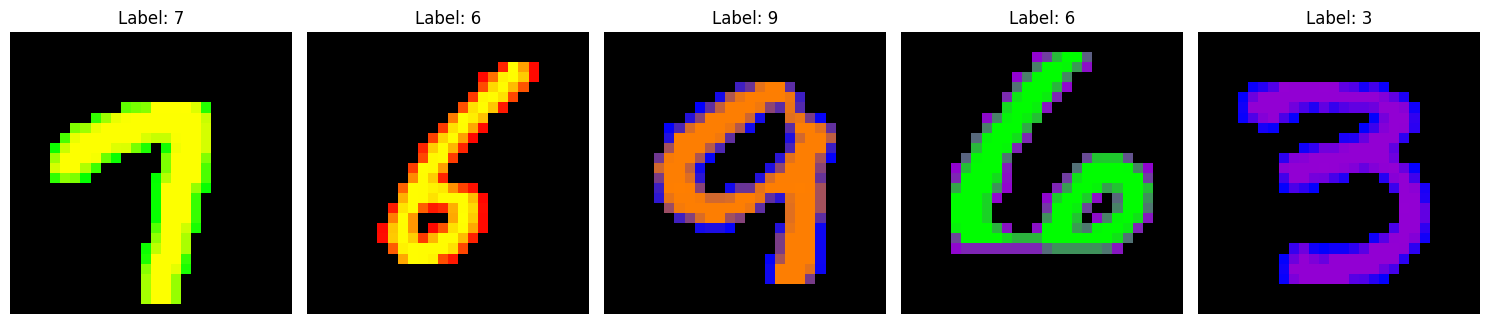

In [4]:
# 배경 검정색 변환
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt
import random
import torch
from torch.utils.data import DataLoader

def replace_color_with_black(image, target_color):
    """이미지에서 target_color와 일치하는 색상을 검정색으로 변경합니다."""
    image_np = np.array(image)  # (H, W, 3) 형태로 변환
    target_color = np.array(target_color)

    # target_color와 동일한 픽셀을 찾고, 그 픽셀을 검정색으로 변경
    mask = np.all(image_np[:, :, :3] == target_color, axis=-1)  # RGB 채널에서 일치하는 색상 찾기
    image_np[mask] = [0, 0, 0]  # 해당 픽셀을 검정색으로 설정

    # 수정된 이미지를 다시 RGB PIL 이미지로 변환
    return Image.fromarray(image_np, mode='RGB')  # RGB 모드로 강제 변환


# black_image 생성 (인덱스 추적을 통해 효율적인 처리)
black_image = []

for idx, image in enumerate(all_images):
    # 각 이미지에 대한 most_common_color를 사용하여 target_color로 검정색으로 바꿈
    target_color = most_common_color[idx]
    final_image_with_black_border = replace_color_with_black(image, target_color)
    black_image.append(final_image_with_black_border)

# 데이터 로더를 다시 만듭니다.
colored_mnist_dataset.colored_images = black_image
colored_mnist_loader = DataLoader(colored_mnist_dataset, batch_size=64, shuffle=True)

# 변경된 이미지 일부를 시각적으로 확인합니다.
dataiter = iter(colored_mnist_loader)
images, labels = next(dataiter)

fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for i in range(5):
    axes[i].imshow(transforms.ToPILImage()(images[i]))
    axes[i].axis('off')
    axes[i].set_title(f'Label: {labels[i].item()}')
plt.tight_layout()
plt.show()


#####2. 전경분류

Foreground Color = ORANGE


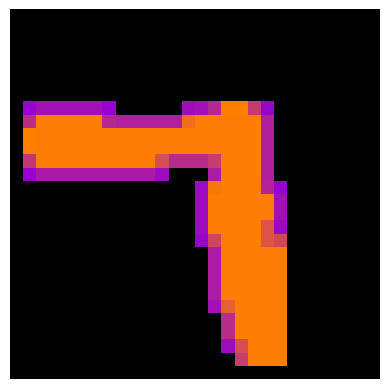

In [5]:
import numpy as np
from collections import Counter
import random
import matplotlib.pyplot as plt

BLACK = (0, 0, 0)  # 검정색 정의

def find_most_common_non_black(image):
    """
    검정색 외에 가장 빈도수가 높은 픽셀 색상을 반환합니다.
    - image: PIL Image 객체 (H, W, 3)
    """
    # PIL 이미지 -> NumPy 배열로 변환
    image_array = np.array(image)

    # 검정색이 아닌 모든 픽셀 필터링
    non_black_pixels = image_array[(image_array != BLACK).any(axis=-1)]

    # 검정색 외 가장 빈도수가 높은 색상 반환
    if len(non_black_pixels) == 0:
        return None  # 검정색 이외의 픽셀이 없는 경우
    most_common_color = Counter(map(tuple, non_black_pixels)).most_common(1)
    return most_common_color[0][0]

def find_closest_color(target_color, color_palette):
    target_color = np.array(target_color)  # 목표 색상
    color_palette = np.array(color_palette)  # 색상 팔레트

    # 각 색상과 목표 색상 간의 유클리드 거리 계산
    distances = np.linalg.norm(color_palette - target_color, axis=1)

    # 가장 가까운 색상 찾기
    closest_index = np.argmin(distances)

    return tuple(color_palette[closest_index]), RAINBOW_NAMES[closest_index]

foreground_color = []
closest_color = []
closest_color_name = []

for idx, image in enumerate(colored_mnist_dataset.colored_images):
    # 검정색이 아닌 가장 빈도 높은 색상 찾기
    fg_color = find_most_common_non_black(image)
    if fg_color is not None:
        foreground_color.append(fg_color)
        color, color_name = find_closest_color(fg_color, RAINBOW_COLORS)
        closest_color.append(color)
        closest_color_name.append(color_name)
    else:
        # 검정색 이외의 색상이 없는 경우 처리
        foreground_color.append(BLACK)
        closest_color.append(BLACK)
        closest_color_name.append("BLACK")

# 무작위로 이미지 선택 및 결과 출력
image = random.choice(colored_mnist_dataset.colored_images)
index = colored_mnist_dataset.colored_images.index(image)


# 출력
print(f"Foreground Color = {closest_color_name[index]}")

# 결과 이미지 출력
plt.imshow(image)
plt.axis('off')
plt.show()


## Component3. 숫자 분류기

### 1.데이터 분할

##### 1-0. 컨포넌트 2의 입력이미지를 HSV 색공간으로 변환 후 1채널의 그레이스케일 이미지로 전환

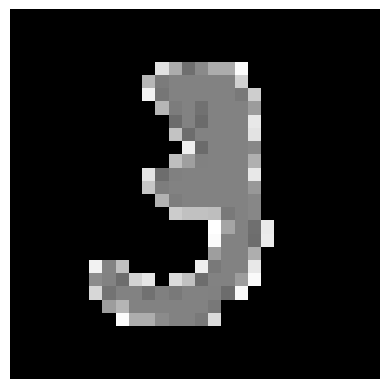

In [6]:
import numpy as np
import cv2
from PIL import Image
import torch

# HSV 색공간으로 변환 후 V 채널 추출하여 그레이스케일 변환 함수 정의
def convert_to_grayscale_hsv(all_images):
    converted_images = []

    for img in all_images:
        # PIL 이미지를 NumPy 배열로 변환
        img_np = np.array(img)  # (H, W) 형태의 NumPy 배열

        # HSV 색공간으로 변환
        hsv_img = cv2.cvtColor(img_np, cv2.COLOR_RGB2HSV)

        # V 채널 (명도) 추출
        value_channel = hsv_img[:, :, 2]  # V 채널은 세 번째 채널입니다.

        # V 채널을 PIL 그레이스케일 이미지로 변환
        grayscale_image = Image.fromarray(value_channel)

        # 변환된 이미지를 리스트에 추가
        converted_images.append(grayscale_image)

    return converted_images

# HSV -> 그레이스케일 변환
colored_mnist_dataset.colored_images = convert_to_grayscale_hsv(colored_mnist_dataset.colored_images)

# 변환된 이미지 확인 (첫 번째 이미지 출력)
plt.imshow(colored_mnist_dataset.colored_images[10], cmap='gray')
plt.axis('off')
plt.show()


변환 전과 변환 후 이미지 살펴보기

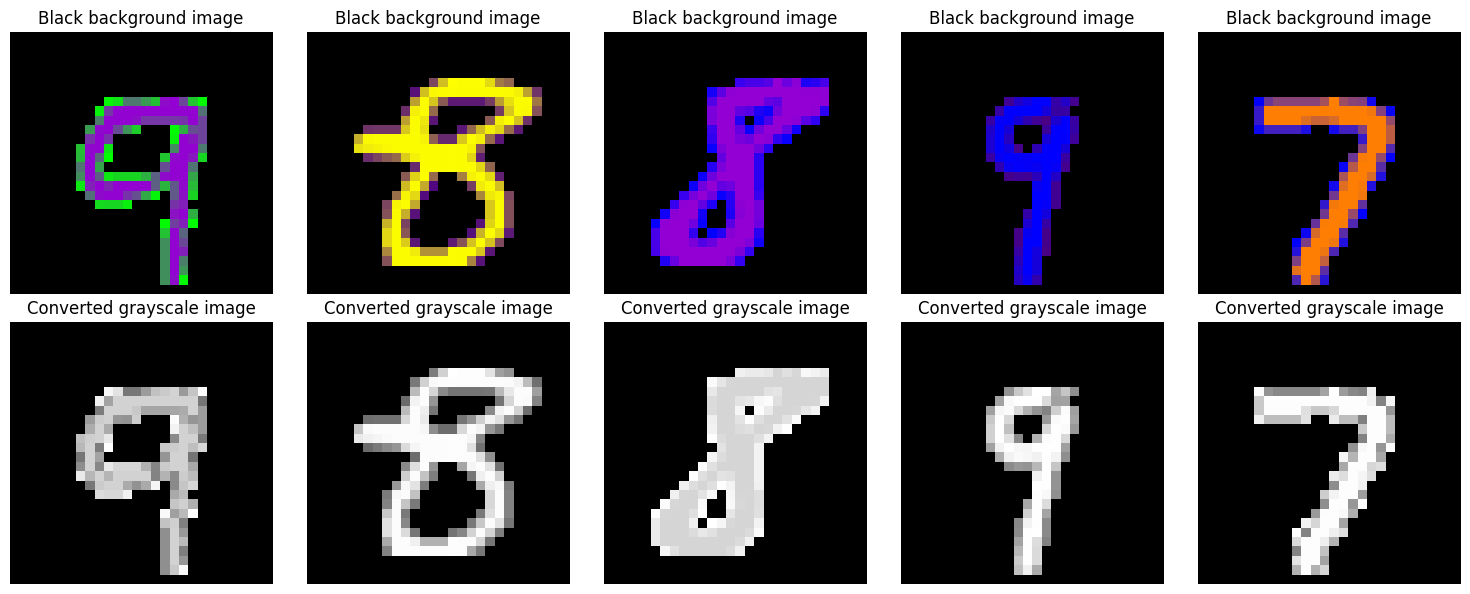

In [7]:
import matplotlib.pyplot as plt

# 특정 인덱스를 선택 (10개의 무작위 이미지 선택)
indices = random.sample(range(len(colored_mnist_dataset.colored_images)), 5)

# 원본 이미지와 변환된 이미지 가져오기
original_images = [black_image[i] for i in indices]  # 변환 전 이미지
converted_images = [colored_mnist_dataset.colored_images[i] for i in indices]  # 변환 후 이미지

# 원본과 변환된 이미지를 한 줄에 출력
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, idx in enumerate(indices):
    # 변환 전 이미지
    axes[0, i].imshow(original_images[i])
    axes[0, i].axis('off')
    axes[0, i].set_title(f"Black background image")

    # 변환 후 이미지
    axes[1, i].imshow(converted_images[i], cmap='gray')
    axes[1, i].axis('off')
    axes[1, i].set_title(f"Converted grayscale image")

plt.tight_layout()
plt.show()


머신러닝 모델의 학습데이터로 사용할 데이터 셋 만들기

In [8]:
import torch
from torch.utils.data import TensorDataset
from torchvision.transforms import ToTensor

# 1. 이미지를 PyTorch 텐서로 변환
to_tensor = ToTensor()  # PIL 이미지를 PyTorch 텐서로 변환
tensor_images = torch.stack([to_tensor(img) for img in colored_mnist_dataset.colored_images])  # (N, 1, H, W)

# 2. 레이블을 PyTorch 텐서로 변환
tensor_labels = torch.tensor(all_labels, dtype=torch.long)

# 3. TensorDataset 생성
grayscale_dataset = TensorDataset(tensor_images, tensor_labels)

# 데이터셋 크기 확인
print(f"Grayscale Dataset Size: {len(grayscale_dataset)}")
print(f"첫 번째 샘플 크기: {grayscale_dataset[0][0].shape}, 레이블: {grayscale_dataset[0][1]}")

Grayscale Dataset Size: 60000
첫 번째 샘플 크기: torch.Size([1, 28, 28]), 레이블: 5


#####1-1. 데이터 분할: 훈련 데이터 40,000개, 검증 데이터 20,000개



In [9]:
from torch.utils.data import Subset
import random

def split_colored_mnist_dataset(dataset):
    # 각 레이블별로 최대 4,000개를 훈련 데이터로, 나머지를 검증 데이터로 분리
    label_count = {i: 0 for i in range(10)}  # 레이블별 카운트를 초기화
    train_indices = []
    validation_indices = []

    for idx in range(len(dataset)):  # 전체 데이터셋 순회
        _, label = dataset[idx]  # 이미지와 레이블 가져오기
        if label_count[label] < 4000:  # 해당 레이블의 훈련 데이터가 4000개 미만인 경우
            train_indices.append(idx)
            label_count[label] += 1
        else:
            validation_indices.append(idx)

    # 훈련 데이터셋과 검증 데이터셋 생성
    train_dataset = Subset(dataset, train_indices)
    validation_dataset = Subset(dataset, validation_indices)

    return train_dataset, validation_dataset

# 데이터셋 분할 실행
train_dataset, validation_dataset = split_colored_mnist_dataset(colored_mnist_dataset)

# 결과 출력 (데이터셋의 크기 확인)
print(f"Train Dataset Size: {len(train_dataset)}")
print(f"Validation Dataset Size: {len(validation_dataset)}")


Train Dataset Size: 40000
Validation Dataset Size: 20000


### 2. 데이터 증강

##### 2-1.EMNIST 1만개 : 먼저 증강할 데이터 4만개 중 만개를 EMNIST의 digits 데이터의에서 계층적 샘플링을 통해 만개를 불러온다

In [10]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
from collections import Counter
import random

# 1. EMNIST Digit 데이터셋 로드
transform = transforms.Compose([
    transforms.ToTensor(),  # 텐서로 변환
    transforms.Normalize((0.5,), (0.5,))  # 정규화
])

emnist_dataset = datasets.EMNIST(
    root='./data',
    split='digits',  # Digits 데이터셋
    train=True,
    download=True,
    transform=transform
)

# 2. 클래스 분포 확인
labels = [label for _, label in emnist_dataset]  # 모든 레이블 추출
class_counts = Counter(labels)  # 클래스별 샘플 수
print(f"클래스 분포: {class_counts}")

# 3. 계층적 샘플링: 각 클래스에서 비율에 따라 샘플링
def stratified_sampling(dataset, num_samples):
    labels = np.array([label for _, label in dataset])  # 레이블 리스트
    num_classes = len(set(labels))  # 클래스 개수
    samples_per_class = num_samples // num_classes  # 각 클래스에서 추출할 샘플 수

    indices = []  # 선택된 인덱스 저장

    for class_idx in range(num_classes):
        # 해당 클래스의 인덱스 추출
        class_indices = np.where(labels == class_idx)[0]
        # 클래스에서 무작위로 샘플 선택
        sampled_indices = random.sample(list(class_indices), samples_per_class)
        indices.extend(sampled_indices)

    # 최종 샘플링된 인덱스 반환
    return indices

# 4. 1만 개 데이터 추출
num_samples = 10000
sampled_indices = stratified_sampling(emnist_dataset, num_samples)

# 5. 샘플링된 데이터로 서브셋 생성
sampled_dataset = Subset(emnist_dataset, sampled_indices)

# 6. 데이터 로더 생성 (옵션)
data_loader = DataLoader(sampled_dataset, batch_size=64, shuffle=True)

# 확인: 샘플링된 데이터의 클래스 분포
sampled_labels = [label for _, label in sampled_dataset]
print(f"샘플링된 클래스 분포: {Counter(sampled_labels)}")


100%|██████████| 562M/562M [00:07<00:00, 78.0MB/s]


Extracting ./data/EMNIST/raw/gzip.zip to ./data/EMNIST/raw
클래스 분포: Counter({8: 24000, 9: 24000, 6: 24000, 3: 24000, 7: 24000, 1: 24000, 0: 24000, 4: 24000, 5: 24000, 2: 24000})
샘플링된 클래스 분포: Counter({0: 1000, 1: 1000, 2: 1000, 3: 1000, 4: 1000, 5: 1000, 6: 1000, 7: 1000, 8: 1000, 9: 1000})


불러온 EMNIST 데이터를 확인하면 다음과 같다

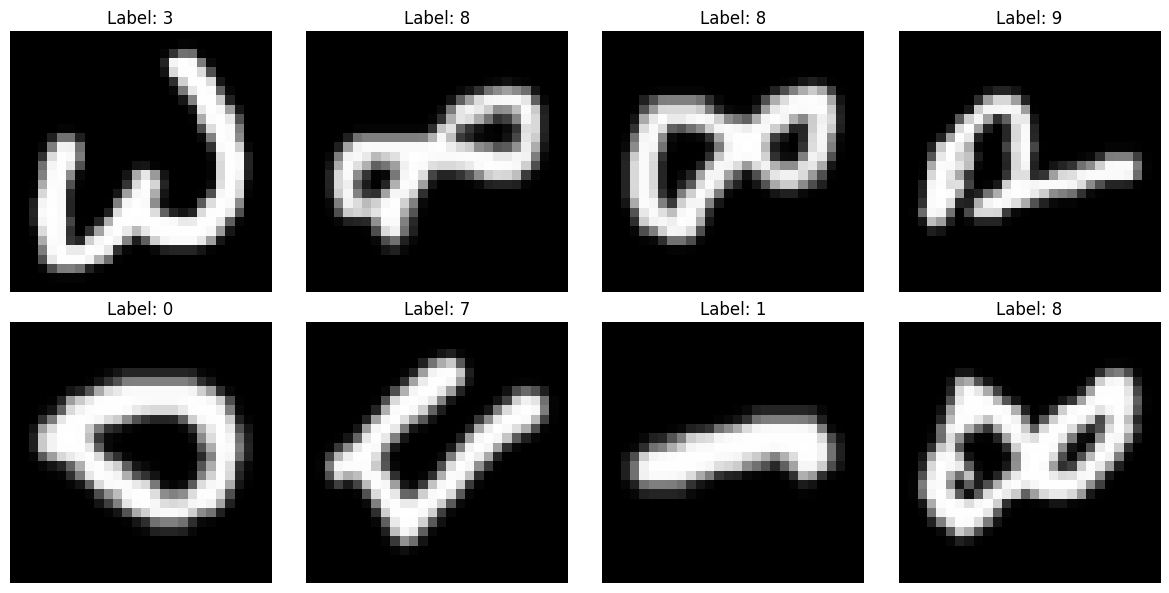

In [11]:
import matplotlib.pyplot as plt

# 데이터 로더에서 첫 번째 배치 가져오기
data_iter = iter(data_loader)
images, labels = next(data_iter)

# 시각화 함수 정의
def show_images(images, labels, num_images=8):
    plt.figure(figsize=(12, 6))
    for i in range(num_images):
        plt.subplot(2, num_images // 2, i + 1)
        plt.imshow(images[i].squeeze(), cmap='gray')  # 1채널 이미지를 2D로 시각화
        plt.title(f"Label: {labels[i].item()}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# 샘플 데이터 시각화
show_images(images, labels)


##### 2-2. 폰트 증강 : 4만개 중 3만개는 폰트를 이용한 데이터 증강 기법을 사용한다. 그런다음 elastic, shear, random 을 이용하여 손글씨와 유사하게 만든다.

In [13]:
from PIL import Image, ImageDraw, ImageFont
import numpy as np
import random
import matplotlib.pyplot as plt
from glob import glob
from torchvision import transforms
from scipy.ndimage import map_coordinates, gaussian_filter
from collections import Counter

# 1. 폰트 경로 설정
FONT_PATHS = glob('./fonts/*.ttf', recursive=True)

# MNIST와 유사한 이미지 크기 및 폰트 크기 설정
IMAGE_SIZE = (28, 28)
FONT_SIZE = 22

def generate_digit_image(digit, font_path):
    """ 주어진 폰트로 특정 숫자 이미지를 생성하는 함수 """
    # 흰 배경의 이미지를 생성합니다.
    image = Image.new("L", IMAGE_SIZE, 0)  # 흰 배경 이미지 (L 모드는 그레이스케일)
    draw = ImageDraw.Draw(image)  # 이미지를 그리기 위한 객체 생성

    try:
        # 지정된 경로에서 폰트를 불러옵니다.
        font = ImageFont.truetype(font_path, FONT_SIZE)
    except IOError:
        # 폰트를 불러올 수 없는 경우 오류 메시지 출력
        print(f"폰트를 불러올 수 없습니다: {font_path}")
        return None

    # 텍스트(숫자)의 경계 상자를 계산합니다.
    bbox = draw.textbbox((0, 0), str(digit), font=font)
    text_width, text_height = bbox[2] - bbox[0], bbox[3] - bbox[1]

    # 텍스트를 이미지의 중앙에 배치합니다.
    position = ((IMAGE_SIZE[0] - text_width) // 2, 0)  # 위쪽에 정렬

    # 검은색(값 0)으로 숫자를 이미지에 그립니다.
    draw.text(position, str(digit), fill=255, font=font)

    return np.array(image)  # 생성된 이미지를 넘파이 배열로 반환

# 2. Elastic Transform 적용 함수
def elastic_transform(image, alpha, sigma):
    """Elastic Transform을 이미지에 적용"""
    random_state = np.random.RandomState(None)
    shape = image.shape

    dx = gaussian_filter((random_state.rand(*shape) * 2 - 1), sigma, mode="constant", cval=0) * alpha
    dy = gaussian_filter((random_state.rand(*shape) * 2 - 1), sigma, mode="constant", cval=0) * alpha

    x, y = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))
    indices = np.reshape(y + dy, (-1, 1)), np.reshape(x + dx, (-1, 1))

    distorted_image = map_coordinates(image, indices, order=1).reshape(shape)
    return distorted_image

# 3. 데이터 증강 Transform 정의
augmentation = transforms.Compose([
    transforms.ToTensor(),  # PIL 이미지를 텐서로 변환
    transforms.RandomAffine(degrees=10, shear=10),  # Shear 변환과 랜덤 회전
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.1), ratio=(0.5, 1.5), value=0)  # Random Erasing
])

# 4. 데이터 생성 및 증강 (라벨당 일정 개수씩 생성)
def generate_and_augment_data_per_label(num_samples_per_label=3000):
    """라벨 당 num_samples_per_label 개씩 데이터 생성 및 증강"""
    font_files = FONT_PATHS
    augmented_images = []
    augmented_labels = []

    for digit in range(10):  # 0부터 9까지 각 라벨별로 생성
        count = 0
        while count < num_samples_per_label:
            # 랜덤 폰트 선택
            font_path = random.choice(font_files)

            # 숫자 이미지 생성
            image = generate_digit_image(digit, font_path)
            if image is None:
                continue

            # Elastic Transform 적용
            image = elastic_transform(image, alpha=5, sigma=3)

            # 이미지 증강 (Shear Transform과 Random Erasing)
            image = Image.fromarray(image)
            image = augmentation(image)

            # 결과 저장
            augmented_images.append(np.array(image))  # 증강된 이미지를 리스트에 저장
            augmented_labels.append(digit)  # 레이블 저장

            count += 1

    return augmented_images, augmented_labels

# 5. 데이터 생성 실행
augmented_images, augmented_labels = generate_and_augment_data_per_label(num_samples_per_label=3000)

# 6. 각 라벨 개수 출력
def count_labels(labels):
    """각 레이블의 데이터 개수를 세는 함수"""
    label_counts = Counter(labels)
    for label, count in sorted(label_counts.items()):
        print(f"Label {label}: {count} images")

# 라벨 개수 확인
count_labels(augmented_labels)

Label 0: 3000 images
Label 1: 3000 images
Label 2: 3000 images
Label 3: 3000 images
Label 4: 3000 images
Label 5: 3000 images
Label 6: 3000 images
Label 7: 3000 images
Label 8: 3000 images
Label 9: 3000 images


##### 2-3. 4만개의 데이터 셋으로 합치기

In [14]:
from torch.utils.data import DataLoader, Subset, ConcatDataset, TensorDataset
# 7. 폰트 증강 데이터를 텐서로 변환

font_images_tensor = torch.tensor(augmented_images, dtype=torch.float32)
font_labels_tensor = torch.tensor(augmented_labels, dtype=torch.long)
font_dataset = TensorDataset(font_images_tensor, font_labels_tensor)

# 8. EMNIST 데이터셋과 폰트 증강 데이터셋 결합
combined_dataset = ConcatDataset([sampled_dataset, font_dataset])

# 10. 확인: 결합된 데이터셋의 크기 출력
print(f"총 데이터셋 크기: {len(combined_dataset)}")

for image, label in combined_dataset:
    print(f"결합된 데이터 크기: {image.shape}")
    break

총 데이터셋 크기: 40000
결합된 데이터 크기: torch.Size([1, 28, 28])


<ipython-input-14-cbedb8b5dd72>:4: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  font_images_tensor = torch.tensor(augmented_images, dtype=torch.float32)


#####2-4. 8만개의 훈련 데이터 셋 완성하기

Augmented train data set Size: 80000
샘플 이미지 텐서 형태: torch.Size([1, 28, 28])
샘플 레이블: 0


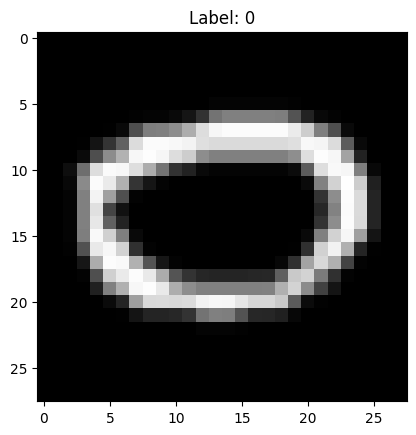

In [15]:
from torch.utils.data import ConcatDataset

# 두 데이터셋을 합쳐서 하나의 데이터셋으로 만듭니다.
augmented_train_dataset = ConcatDataset([combined_dataset, train_dataset])

# 합쳐진 데이터셋 크기 확인
print(f"Augmented train data set Size: {len(augmented_train_dataset)}")

# 데이터셋의 첫 번째 샘플 확인
sample_image, sample_label = augmented_train_dataset[0]

# 샘플 이미지와 레이블 출력
print(f"샘플 이미지 텐서 형태: {sample_image.shape}")
print(f"샘플 레이블: {sample_label}")

# 첫 번째 샘플의 이미지를 시각적으로 확인
import matplotlib.pyplot as plt

# 이미지를 시각화하기 위해 차원을 조정합니다.
# Grayscale 이미지이므로 squeeze()를 사용해 채널 차원을 제거합니다.
plt.imshow(sample_image.squeeze(), cmap='gray')
plt.title(f"Label: {sample_label}")
plt.show()


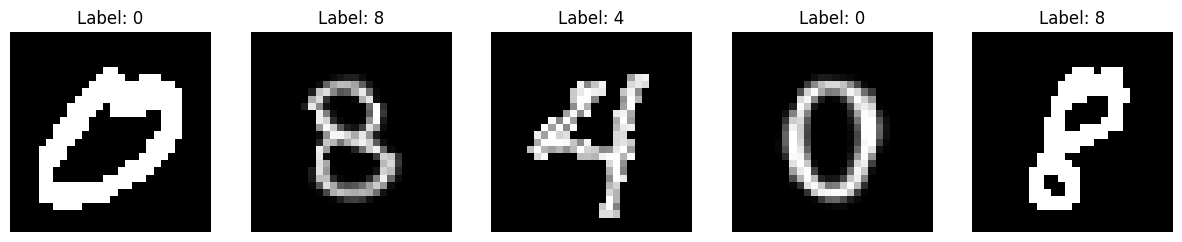

In [16]:
# 임의로 5개 샘플 이미지와 레이블 출력
import random

# 데이터셋에서 임의의 5개 인덱스 선택
random_indices = random.sample(range(len(augmented_train_dataset)), 5)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, ax in enumerate(axes):
    img, label = augmented_train_dataset[random_indices[i]]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f"Label: {label}")
    ax.axis('off')
plt.show()


### 3. 데이터 전처리

##### 3-1. 정규화하기

In [17]:
import torch
from torch.utils.data import ConcatDataset, TensorDataset, Subset

# Subset의 실제 데이터셋 가져오기
def get_base_dataset(dataset):
    if isinstance(dataset, Subset):
        return dataset.dataset  # Subset의 원래 데이터셋 반환
    return dataset  # Subset이 아니면 그대로 반환

# 정규화를 위한 함수 정의
def min_max_normalize(dataset):
    normalized_datasets = []

    # ConcatDataset 내부 데이터셋 순회
    for sub_dataset in dataset.datasets:
        # Subset 처리
        base_dataset = get_base_dataset(sub_dataset)

        # TensorDataset 또는 인덱싱 가능한 데이터셋 처리
        if hasattr(base_dataset, "__getitem__"):
            images_list = []
            labels_list = []

            # Subset 또는 기본 데이터셋에서 각 샘플에 접근
            for idx in range(len(sub_dataset)):
                image, label = sub_dataset[idx]  # 이미지와 레이블 추출
                images_list.append(image)
                labels_list.append(label)

            # 텐서로 변환
            images = torch.stack(images_list)  # (N, C, H, W)
            labels = torch.tensor(labels_list)  # (N,)

            # Min-Max 정규화
            min_val = images.min()
            max_val = images.max()
            normalized_images = (images - min_val) / (max_val - min_val)

            # 정규화된 TensorDataset 추가
            normalized_datasets.append(TensorDataset(normalized_images, labels))
        else:
            raise TypeError(f"Unsupported dataset type: {type(base_dataset)}")

    # 정규화된 데이터셋들을 다시 ConcatDataset으로 병합
    return ConcatDataset(normalized_datasets)

# Min-Max 정규화를 ConcatDataset에 적용
normalized_augmented_train_dataset = min_max_normalize(augmented_train_dataset)

# 확인
print(f"Original Dataset Size: {len(augmented_train_dataset)}")
print(f"Normalized Dataset Size: {len(normalized_augmented_train_dataset)}")

# 샘플 확인
sample_image, sample_label = normalized_augmented_train_dataset[0]
print(f"Sample Image Shape: {sample_image.shape}, Min: {sample_image.min()}, Max: {sample_image.max()}")
print(f"Sample Label: {sample_label}")


Original Dataset Size: 80000
Normalized Dataset Size: 80000
Sample Image Shape: torch.Size([1, 28, 28]), Min: 0.0, Max: 1.0
Sample Label: 0


#####3-2. 원 핫 인코딩

In [18]:
import torch
from torch.utils.data import ConcatDataset, TensorDataset, Subset

# Subset의 실제 데이터셋 가져오기
def get_base_dataset(dataset):
    if isinstance(dataset, Subset):
        return dataset.dataset  # Subset의 원래 데이터셋 반환
    return dataset  # Subset이 아니면 그대로 반환

# 원핫 인코딩을 적용하는 함수 정의
def one_hot_encode_dataset(dataset, num_classes):
    one_hot_encoded_datasets = []

    # ConcatDataset 내부 데이터셋 순회
    for sub_dataset in dataset.datasets:
        base_dataset = get_base_dataset(sub_dataset)

        if hasattr(base_dataset, "__getitem__"):
            images_list = []
            labels_list = []

            # Subset 또는 기본 데이터셋에서 각 샘플에 접근
            for idx in range(len(sub_dataset)):
                image, label = sub_dataset[idx]  # 이미지와 레이블 추출
                images_list.append(image)
                labels_list.append(label)

            # 텐서로 변환
            images = torch.stack(images_list)  # (N, C, H, W)
            labels = torch.tensor(labels_list)  # (N,)

            # 원핫 인코딩 수행
            one_hot_labels = torch.nn.functional.one_hot(labels, num_classes=num_classes)  # (N, num_classes)

            # 원핫 인코딩된 TensorDataset 추가
            one_hot_encoded_datasets.append(TensorDataset(images, one_hot_labels))
        else:
            raise TypeError(f"Unsupported dataset type: {type(base_dataset)}")

    # 원핫 인코딩된 데이터셋들을 다시 ConcatDataset으로 병합
    return ConcatDataset(one_hot_encoded_datasets)

# 클래스 개수 정의 (예: MNIST는 10개 클래스)
num_classes = 10

# augmented_train_dataset에 원핫 인코딩 적용
one_hot_augmented_train_dataset = one_hot_encode_dataset(augmented_train_dataset, num_classes)

# 확인
print(f"Original Dataset Size: {len(augmented_train_dataset)}")
print(f"One-Hot Encoded Dataset Size: {len(one_hot_augmented_train_dataset)}")

# 첫 번째 샘플 확인
sample_image, sample_label = one_hot_augmented_train_dataset[0]
print(f"Sample Image Shape: {sample_image.shape}")
print(f"Sample Label Shape: {sample_label.shape}, One-Hot Encoded Label: {sample_label}")


Original Dataset Size: 80000
One-Hot Encoded Dataset Size: 80000
Sample Image Shape: torch.Size([1, 28, 28])
Sample Label Shape: torch.Size([10]), One-Hot Encoded Label: tensor([1, 0, 0, 0, 0, 0, 0, 0, 0, 0])


##### 3-3. 데이터 평탄화

In [19]:
import torch
from torch.utils.data import ConcatDataset, TensorDataset, Subset

# Subset의 실제 데이터셋 가져오기
def get_base_dataset(dataset):
    if isinstance(dataset, Subset):
        return dataset.dataset  # Subset의 원래 데이터셋 반환
    return dataset  # Subset이 아니면 그대로 반환

# 평탄화만 적용하는 함수 정의
def apply_flattening(dataset):
    flattened_datasets = []

    # ConcatDataset 내부 데이터셋 순회
    for sub_dataset in dataset.datasets:
        base_dataset = get_base_dataset(sub_dataset)

        # TensorDataset 또는 인덱싱 가능한 데이터셋 처리
        if hasattr(base_dataset, "__getitem__"):
            images_list = []
            labels_list = []

            # Subset 또는 기본 데이터셋에서 각 샘플에 접근
            for idx in range(len(sub_dataset)):
                image, label = sub_dataset[idx]  # 이미지와 레이블 추출
                images_list.append(image)
                labels_list.append(label)

            # 텐서로 변환
            images = torch.stack(images_list)  # (N, C, H, W)
            labels = torch.tensor(labels_list)  # (N,)

            # 평탄화 수행
            flattened_images = images.view(images.size(0), -1)  # (N, C * H * W)

            # 평탄화된 TensorDataset 추가
            flattened_datasets.append(TensorDataset(flattened_images, labels))
        else:
            raise TypeError(f"Unsupported dataset type: {type(base_dataset)}")

    # 평탄화된 데이터셋들을 다시 ConcatDataset으로 병합
    return ConcatDataset(flattened_datasets)

# 평탄화 적용
flattened_augmented_train_dataset = apply_flattening(normalized_augmented_train_dataset)

# 확인
print(f"Processed Dataset Size: {len(flattened_augmented_train_dataset)}")
sample_image, sample_label = flattened_augmented_train_dataset[0]
print(f"Sample Flattened Image Shape: {sample_image.shape}")  # 평탄화된 이미지 크기
print(f"Sample Label: {sample_label}")


Processed Dataset Size: 80000
Sample Flattened Image Shape: torch.Size([784])
Sample Label: 0


##### 3-4. 최종 모델 학습 데이터 정리

In [20]:
import torch
from torch.utils.data import TensorDataset, ConcatDataset

# 평탄화와 정규화가 완료된 데이터셋 (예: normalized_and_flattened_dataset)
# 원핫 인코딩된 데이터셋 (예: one_hot_augmented_train_dataset)

def combine_flattened_and_one_hot_datasets(flattened_dataset, one_hot_dataset):
    combined_datasets = []

    # 두 데이터셋 내부를 순회하며 결합
    for flattened_sub_dataset, one_hot_sub_dataset in zip(flattened_dataset.datasets, one_hot_dataset.datasets):
        # 평탄화된 데이터셋에서 이미지와 레이블 분리
        flattened_images, _ = flattened_sub_dataset.tensors  # (N, C * H * W)
        # 원핫 인코딩된 데이터셋에서 레이블 분리
        _, one_hot_labels = one_hot_sub_dataset.tensors  # (N, num_classes)

        # 새로운 TensorDataset 생성
        combined_datasets.append(TensorDataset(flattened_images, one_hot_labels))

    # 병합된 데이터셋으로 ConcatDataset 생성
    return ConcatDataset(combined_datasets)

# train_dataset 생성
train_dataset = combine_flattened_and_one_hot_datasets(flattened_augmented_train_dataset, one_hot_augmented_train_dataset)

# 확인
print(f"Combined Dataset Size: {len(train_dataset)}")

# 첫 번째 샘플 확인
sample_image, sample_label = train_dataset[0]
print(f"Sample Image Shape: {sample_image.shape}")  # 평탄화된 이미지 크기
print(f"Sample Label Shape: {sample_label.shape}, One-Hot Encoded Label: {sample_label}")

Combined Dataset Size: 80000
Sample Image Shape: torch.Size([784])
Sample Label Shape: torch.Size([10]), One-Hot Encoded Label: tensor([1, 0, 0, 0, 0, 0, 0, 0, 0, 0])


### 4. 모델 학습

##### 4-0. 검증데이터 전처리

In [21]:
import numpy as np
from sklearn.metrics import accuracy_score
import torch

# 정규화 함수
def min_max_normalize_images(images):
    min_val = images.min()
    max_val = images.max()
    return (images - min_val) / (max_val - min_val)

# 평탄화 함수
def flatten_images(images):
    return images.view(images.size(0), -1)  # (N, C * H * W)

# Subset에 전처리를 적용하는 함수
def preprocess_subset(subset, num_classes):
    # Subset의 원래 데이터셋과 인덱스 추출
    dataset = subset.dataset
    indices = subset.indices

    images_list = []
    labels_list = []

    for idx in indices:
        image, label = dataset[idx]  # 인덱스를 사용해 데이터 추출

        # 정규화
        normalized_image = min_max_normalize_images(image.unsqueeze(0))  # (1, C, H, W)
        flattened_image = flatten_images(normalized_image)  # (1, C * H * W)

        images_list.append(flattened_image)
        labels_list.append(label)

    # 데이터를 병합
    all_images = torch.cat(images_list, dim=0).numpy()  # (N, C * H * W)
    all_labels = torch.tensor(labels_list).numpy()  # 정수형 라벨

    return all_images, all_labels

# 클래스 개수 정의 (예: MNIST는 10개 클래스)
num_classes = 10

# validation_dataset 전처리
X_val, y_val = preprocess_subset(validation_dataset, num_classes)

##### 4-1. KNN

In [22]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

# train_dataset에서 데이터를 추출
def extract_data_from_train_dataset(dataset):
    images_list = []
    labels_list = []

    for sub_dataset in dataset.datasets:
        images, labels = sub_dataset.tensors
        images_list.append(images.numpy())
        labels_list.append(labels.numpy())

    # 데이터를 병합
    all_images = np.vstack(images_list)  # (N, C * H * W)
    all_labels = np.vstack(labels_list)  # (N, num_classes)
    return all_images, np.argmax(all_labels, axis=1)  # 정수형 라벨 반환

# train_dataset에서 이미지와 라벨 추출
X_train, y_train = extract_data_from_train_dataset(train_dataset)


# KNN 모델 초기화 및 학습
k = 5  # K값 설정
knn_model = KNeighborsClassifier(n_neighbors=k)
knn_model.fit(X_train, y_train)


# KNN 모델을 이용해 예측
y_val_pred = knn_model.predict(X_val)

# 정확도 계산
val_accuracy = accuracy_score(y_val, y_val_pred)

# F1 Score 계산
val_f1_score = f1_score(y_val, y_val_pred, average='weighted')  # weighted 평균 사용


# 결과 출력
print(f"KNN Validation Accuracy: {val_accuracy * 100:.2f}%")
print(f"KNN Validation F1 Score: {val_f1_score:.2f}")

KNN Validation Accuracy: 95.48%
KNN Validation F1 Score: 0.95


##### 4-2. 랜덤 포레스트

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np

# train_dataset에서 데이터를 추출
def extract_data_from_train_dataset(dataset):
    images_list = []
    labels_list = []

    for sub_dataset in dataset.datasets:  # ConcatDataset 내부 데이터셋 순회
        images, labels = sub_dataset.tensors
        images_list.append(images.numpy())
        labels_list.append(labels.numpy())

    # 데이터를 병합
    all_images = np.vstack(images_list)  # (N, C * H * W)
    all_labels = np.argmax(np.vstack(labels_list), axis=1)  # (N,) 정수형 라벨
    return all_images, all_labels

# train_dataset에서 이미지와 라벨 추출
X_train, y_train = extract_data_from_train_dataset(train_dataset)

# 랜덤 포레스트 모델 초기화
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)  # 100개의 결정 트리 사용

# 모델 학습
random_forest_model.fit(X_train, y_train)

# 모델을 이용해 예측
y_val_pred = random_forest_model.predict(X_val)

# 검증 데이터 정확도 계산
val_accuracy = accuracy_score(y_val, y_val_pred)

# F1-Score 계산
val_f1_score = f1_score(y_val, y_val_pred, average='weighted')  # weighted 평균 사용

# 결과 출력
print(f"Random Forest Validation Accuracy: {val_accuracy * 100:.2f}%")
print(f"Random Forest Validation F1 Score: {val_f1_score:.2f}")

Random Forest Validation Accuracy: 95.67%
Random Forest Validation F1 Score: 0.96


##### 4-3. SVM

In [24]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np

# train_dataset에서 데이터를 추출
def extract_data_from_train_dataset(dataset):
    images_list = []
    labels_list = []

    for sub_dataset in dataset.datasets:  # ConcatDataset 내부 데이터셋 순회
        images, labels = sub_dataset.tensors
        images_list.append(images.numpy())
        labels_list.append(labels.numpy())

    # 데이터를 병합
    all_images = np.vstack(images_list)  # (N, C * H * W)
    all_labels = np.argmax(np.vstack(labels_list), axis=1)  # (N,) 정수형 라벨
    return all_images, all_labels

# train_dataset에서 이미지와 라벨 추출
X_train, y_train = extract_data_from_train_dataset(train_dataset)

# SVM 모델 초기화
svm_model = SVC(kernel='linear', C=1.0, random_state=42)  # 선형 커널 사용

# 모델 학습
svm_model.fit(X_train, y_train)

# SVM 모델을 이용해 예측
y_val_pred = svm_model.predict(X_val)

# 검증 데이터 정확도 계산
val_accuracy = accuracy_score(y_val, y_val_pred)

# F1-Score 계산
val_f1_score = f1_score(y_val, y_val_pred, average='weighted')  # weighted 평균 사용

# 결과 출력
print(f"SVM Validation Accuracy: {val_accuracy * 100:.2f}%")
print(f"SVM Validation F1 Score: {val_f1_score:.2f}")

SVM Validation Accuracy: 87.28%
SVM Validation F1 Score: 0.87


혼동행렬 출력

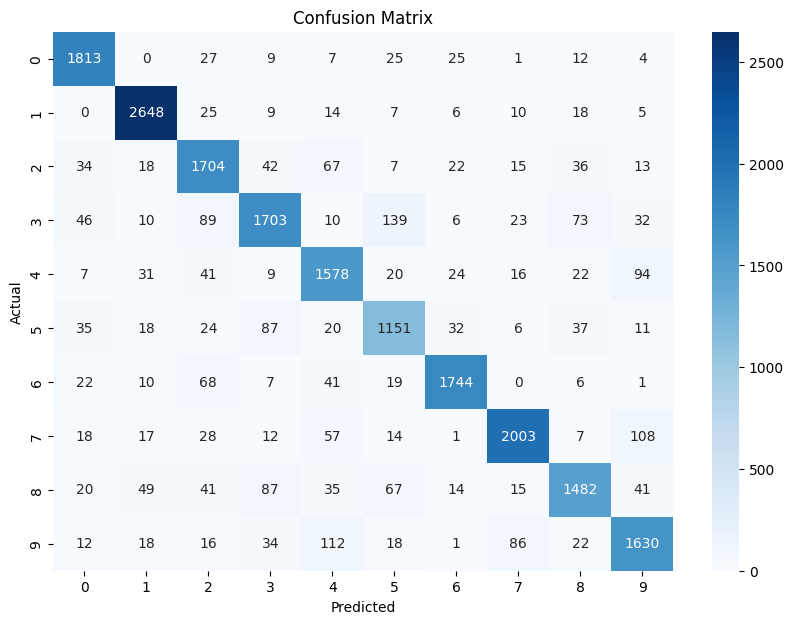

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.94      0.92      1923
           1       0.94      0.97      0.95      2742
           2       0.83      0.87      0.85      1958
           3       0.85      0.80      0.82      2131
           4       0.81      0.86      0.83      1842
           5       0.78      0.81      0.80      1421
           6       0.93      0.91      0.92      1918
           7       0.92      0.88      0.90      2265
           8       0.86      0.80      0.83      1851
           9       0.84      0.84      0.84      1949

    accuracy                           0.87     20000
   macro avg       0.87      0.87      0.87     20000
weighted avg       0.87      0.87      0.87     20000



In [25]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 혼동 행렬 계산
conf_matrix = confusion_matrix(y_val, y_val_pred)

# 혼동 행렬 시각화
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# F1-Score 및 기타 지표 출력
report = classification_report(y_val, y_val_pred, target_names=[str(i) for i in range(10)])
print("Classification Report:\n")
print(report)

###5. 모델 성능 개선

#####5-1. HOG 특성 추출

In [26]:
import numpy as np
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score
import cv2  # OpenCV for resizing images

# HOG 특성 추출 함수
def extract_hog_features(images):
    """
    데이터셋의 이미지에서 HOG 특성을 추출합니다.
    """
    hog_features = []
    for img in images:
        # HOG 특성 추출
        feature = hog(
            img.reshape(28, 28),  # (784,) → (28, 28)으로 복원
            orientations=9,
            pixels_per_cell=(4, 4),
            cells_per_block=(2, 2),
            block_norm='L2-Hys',
            transform_sqrt=True
        )
        hog_features.append(feature)
    return np.array(hog_features)

# HOG 특성 추출
print("Extracting HOG features from train data...")
X_train_hog = extract_hog_features(X_train)

print("Extracting HOG features from validation data...")
X_val_hog = extract_hog_features(X_val)


Extracting HOG features from train data...
Extracting HOG features from validation data...


##### 5-2. 하이퍼 파라미터 튜닝


In [27]:
from sklearn.model_selection import train_test_split, GridSearchCV
# 하이퍼파라미터 최적화
param_grid = {
    'C': [1, 5],
    'kernel': ['linear', 'rbf']
}

# y_train이 원핫 인코딩된 경우 정수형으로 변환
if len(y_train.shape) > 1 and y_train.shape[1] > 1:
    y_train = np.argmax(y_train, axis=1)  # 원핫 인코딩 → 정수형 라벨

grid_search = GridSearchCV(SVC(random_state=42), param_grid, scoring='f1_weighted', cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train_hog , y_train)

# 최적의 하이퍼파라미터 출력
best_params = grid_search.best_params_
print(f"Best Hyperparameters: {best_params}")

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best Hyperparameters: {'C': 5, 'kernel': 'rbf'}


##### 5-3.최적의 SVM 모델로 예측

In [28]:
# 최적의 모델로 예측
best_model = grid_search.best_estimator_
y_val_pred = best_model.predict(X_val_hog)

# 검증 데이터 정확도 및 F1-Score 계산
val_accuracy = accuracy_score(y_val, y_val_pred)
val_f1_score = f1_score(y_val, y_val_pred, average='weighted')

# 결과 출력
print(f"SVM Validation Accuracy with HOG features: {val_accuracy * 100:.2f}%")
print(f"SVM Validation F1 Score with HOG features: {val_f1_score:.2f}")

SVM Validation Accuracy with HOG features: 97.83%
SVM Validation F1 Score with HOG features: 0.98


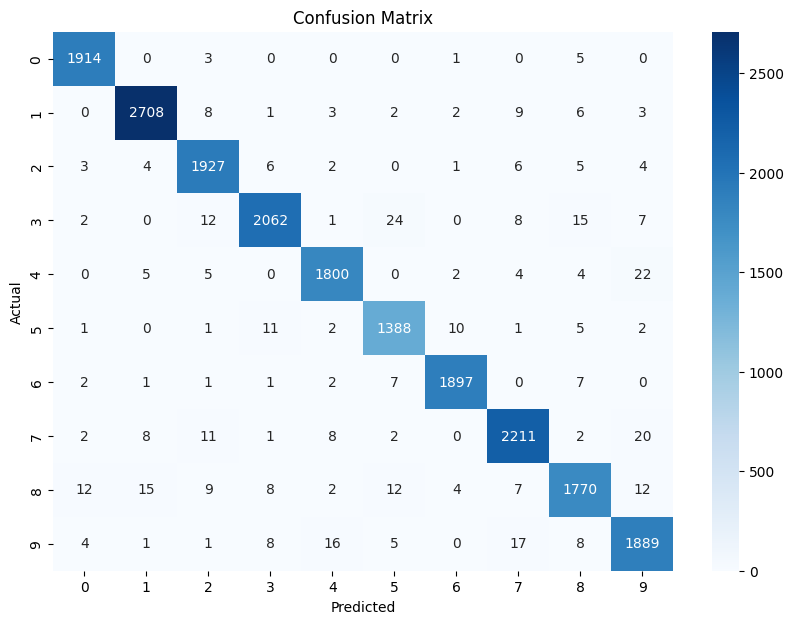

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1923
           1       0.99      0.99      0.99      2742
           2       0.97      0.98      0.98      1958
           3       0.98      0.97      0.98      2131
           4       0.98      0.98      0.98      1842
           5       0.96      0.98      0.97      1421
           6       0.99      0.99      0.99      1918
           7       0.98      0.98      0.98      2265
           8       0.97      0.96      0.96      1851
           9       0.96      0.97      0.97      1949

    accuracy                           0.98     20000
   macro avg       0.98      0.98      0.98     20000
weighted avg       0.98      0.98      0.98     20000



In [29]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 혼동 행렬 계산
conf_matrix = confusion_matrix(y_val, y_val_pred)

# 혼동 행렬 시각화
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# F1-Score 및 기타 지표 출력
report = classification_report(y_val, y_val_pred, target_names=[str(i) for i in range(10)])
print("Classification Report:\n")
print(report)

## 최종 파이프 라인

pipe line input : color MNIST test data


---


- pipe line input => **componet 1** => 배경 출력
- 검정 배경 MNIST input => **componet 2** => 전경 출력
- 검정 배경 MNIST input -> 데이터 전처리 => **componet 3**=> 숫자 출력


---


pipe line output : back-ground label, fore-ground label, number label

####input data : 테스트 데이터 준비

In [30]:
from torchvision import datasets, transforms

# MNIST 테스트 데이터 로드
mnist_test = datasets.MNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())
# 데이터 크기 확인
print(f"Number of test samples: {len(mnist_test)}")

Number of test samples: 10000


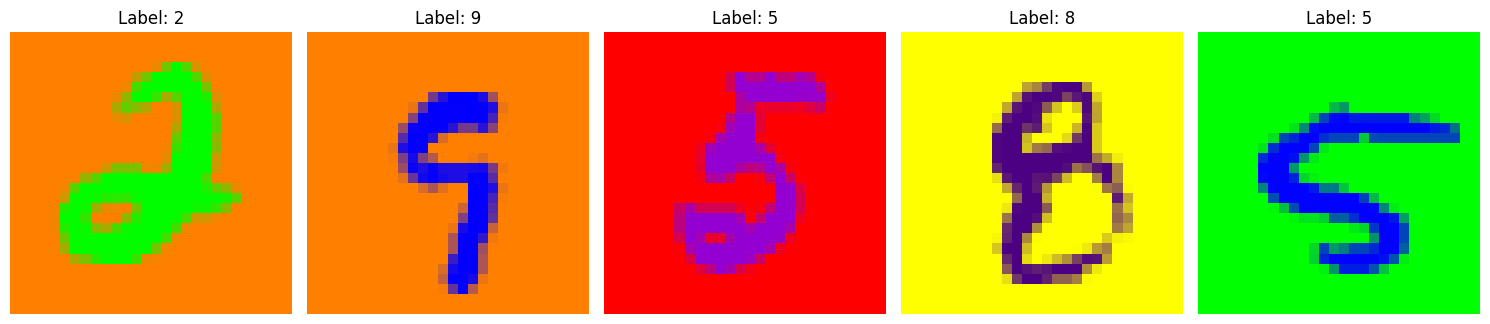

In [31]:
# 컬러화된 MNIST 데이터셋을 생성합니다.
colored_mnist_test_dataset = ColoredMNISTDataset(mnist_test)
colored_mnist_test_loader = DataLoader(colored_mnist_test_dataset, batch_size=64, shuffle=True)

# 모든 컬러화된 이미지와 라벨을 가져옵니다.
all_images_test, all_labels_test = colored_mnist_test_dataset.get_all_images()

# 일부 배치를 시각적으로 확인합니다.
dataiter = iter(colored_mnist_test_loader)
images, labels = next(dataiter)

fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for i in range(5):
    axes[i].imshow(transforms.ToPILImage()(images[i]))
    axes[i].axis('off')
    axes[i].set_title(f'Label: {labels[i].item()}')
plt.tight_layout()
plt.show()

####Component1.후경 분류

Text(0.5, 1.0, 'Background Color: BLUE')

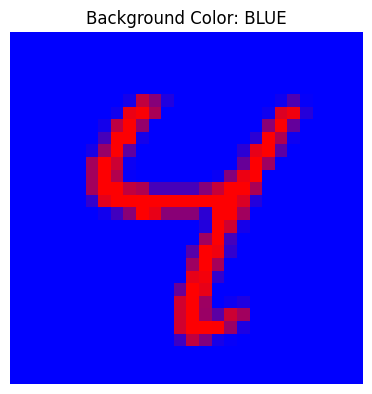

In [32]:
most_common_color_test =[]
most_common_color_name_test = []

for image in all_images_test:
    # 최종 이미지를 사용하여 테두리 색상을 분석합니다.
    border_colors = extract_border_colors(image)  # 테두리 색상 추출
    common_color = most_frequent_color(border_colors)  # 가장 빈도 높은 색상 찾기
    most_common_color_test.append(common_color)
    most_common_color_name_test.append(get_color_name(common_color))  # 해당 색상의 이름 찾기

import random
import matplotlib.pyplot as plt

# 6번 이미지로 파이프라인 결과 확인
index = 6

# 이미지 선택
image = all_images_test[index]  # 첫 번째 코드의 이미지
image_colored = colored_mnist_test_dataset.colored_images[index]  # 두 번째 코드의 이미지

# 결과 출력
border_colors = extract_border_colors(image)
common_color = most_frequent_color(border_colors)
common_color_name = get_color_name(common_color)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.axis('off')
plt.title(f"Background Color: {common_color_name}")

####Component2. 전경 분류

1. 검정 배경 컬러 MNIST으로 변환하기

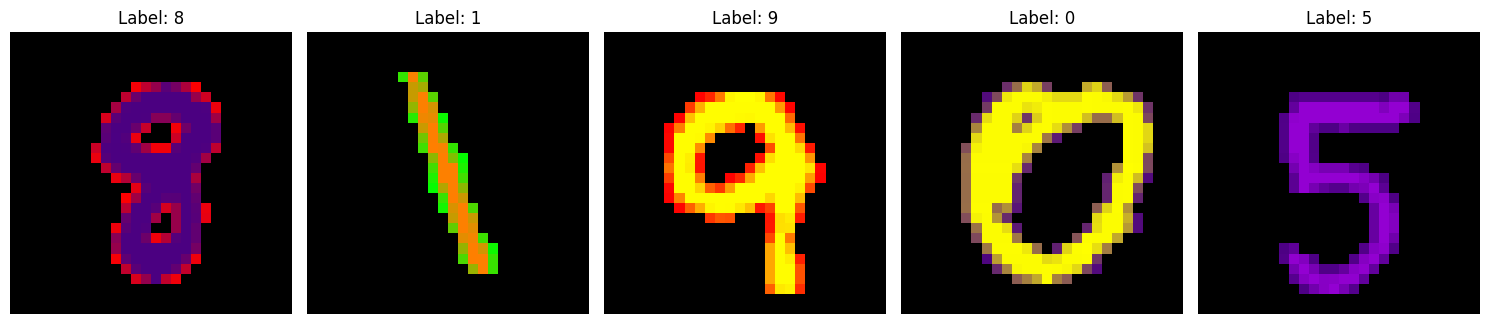

In [33]:
# black_image 생성 (인덱스 추적을 통해 효율적인 처리)
black_image_test = []

for idx, image in enumerate(all_images_test):
    # 각 이미지에 대한 most_common_color를 사용하여 target_color로 검정색으로 바꿈
    target_color = most_common_color_test[idx]
    final_image_with_black_border = replace_color_with_black(image, target_color)
    black_image_test.append(final_image_with_black_border)

# 데이터 로더를 다시 만듭니다.
colored_mnist_test_dataset.colored_images = black_image_test
colored_mnist_test_loader = DataLoader(colored_mnist_test_dataset, batch_size=64, shuffle=True)

# 변경된 이미지 일부를 시각적으로 확인합니다.
dataiter = iter(colored_mnist_test_loader)
images, labels = next(dataiter)

fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for i in range(5):
    axes[i].imshow(transforms.ToPILImage()(images[i]))
    axes[i].axis('off')
    axes[i].set_title(f'Label: {labels[i].item()}')
plt.tight_layout()
plt.show()

2. 전경 분류하기

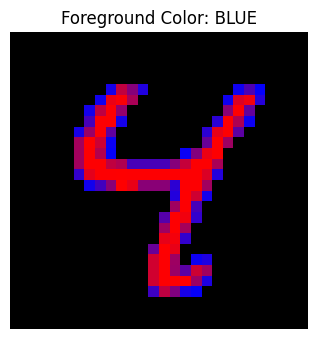

In [34]:
foreground_color_test = []
closest_color_test = []
closest_color_name_test= []

for idx, image in enumerate(colored_mnist_test_dataset.colored_images):
    # 검정색이 아닌 가장 빈도 높은 색상 찾기
    fg_color = find_most_common_non_black(image)
    if fg_color is not None:
        foreground_color_test.append(fg_color)
        color, color_name = find_closest_color(fg_color, RAINBOW_COLORS)
        closest_color_test.append(color)
        closest_color_name_test.append(color_name)
    else:
        # 검정색 이외의 색상이 없는 경우 처리
        foreground_color_test.append(BLACK)
        closest_color_test.append(BLACK)
        closest_color_name_test.append("BLACK")

# 결과 출력
fg_color = find_most_common_non_black(image_colored)
if fg_color is not None:
    color, color_name = find_closest_color(fg_color, RAINBOW_COLORS)
else:
    color_name = "BLACK"

plt.subplot(1, 2, 2)
plt.imshow(black_image_test[6])
plt.axis('off')
plt.title(f"Foreground Color: {color_name}")

plt.tight_layout()
plt.show()


#### Component3. 숫자 분류기

1. 테스트 데이터 전처리

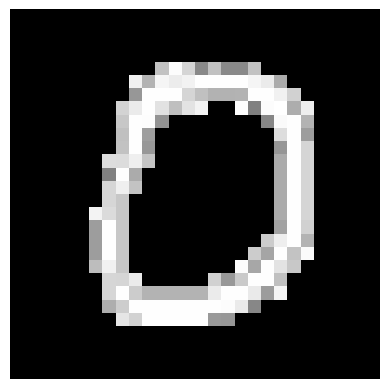

In [35]:
# HSV -> 그레이스케일 변환
colored_mnist_test_dataset.colored_images = convert_to_grayscale_hsv(colored_mnist_test_dataset.colored_images)

# 변환된 이미지 확인 (첫 번째 이미지 출력)
plt.imshow(colored_mnist_test_dataset.colored_images[10], cmap='gray')
plt.axis('off')
plt.show()

In [36]:
import numpy as np
import torch

# 1. 정규화
def normalize_dataset(dataset):
    images_list = []
    labels_list = []

    for image, label in dataset:
        # 이미지 정규화
        normalized_image = (image - image.min()) / (image.max() - image.min())  # Min-Max 정규화
        images_list.append(normalized_image)
        labels_list.append(label)

    # NumPy 배열로 변환
    X_normalized = np.stack(images_list)  # (N, H, W) 또는 (N, C, H, W)
    y = np.array(labels_list)  # (N,)
    return X_normalized, y

# 2. 원핫 인코딩
def one_hot_encode_labels(labels, num_classes):
    return np.eye(num_classes)[labels]  # (N, num_classes)

# 3. 평탄화
def flatten_images(images):
    return images.reshape(images.shape[0], -1)  # (N, H*W)

# 4. HOG 특성 추출
def extract_hog_features(images):
    hog_features = []
    for img in images:
        feature = hog(
            img.reshape(28, 28),  # (H, W)
            orientations=9,
            pixels_per_cell=(4, 4),
            cells_per_block=(2, 2),
            block_norm='L2-Hys',
            transform_sqrt=True
        )
        hog_features.append(feature)
    return np.array(hog_features)

# 전체 처리
num_classes = 10  # 클래스 개수

# 테스트 데이터 정규화
X_test_normalized, y_test = normalize_dataset(colored_mnist_test_dataset)

# 라벨 원핫 인코딩
y_test_one_hot = one_hot_encode_labels(y_test, num_classes)

# 데이터 평탄화
X_test_flattened = flatten_images(X_test_normalized)

# HOG 특성 추출
print("Extracting HOG features from test data...")
X_test_hog = extract_hog_features(X_test_flattened)

# 결과 확인
print(f"HOG Features Shape: {X_test_hog.shape}")
print(f"Labels Shape: {y_test.shape}")


Extracting HOG features from test data...
HOG Features Shape: (10000, 1296)
Labels Shape: (10000,)


2. 최종 모델 SVM에 학습

In [37]:
# 최적의 모델로 테스트 데이터 예측
y_test_pred = best_model.predict(X_test_hog)

파이프라인 결과 확인

Predicted Label for Image 6: 4


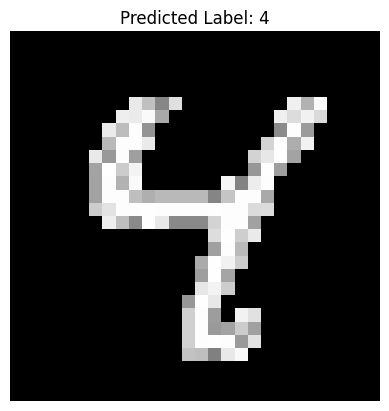

In [38]:
# 이미지 선택 및 전처리
image_to_predict = colored_mnist_test_dataset.colored_images[index]  # PIL 이미지
image_to_predict_np = np.array(image_to_predict)  # NumPy 배열로 변환

# 테스트 데이터 정규화 (정규화 함수가 필요할 경우 구현 또는 호출)
image_normalized = image_to_predict_np / 255.0  # 픽셀 값을 [0, 1]로 정규화

# 데이터 평탄화
image_flattened = image_normalized.flatten().reshape(1, -1)  # (1, H * W)

# HOG 특성 추출
image_hog_feature = extract_hog_features(image_flattened)

# 모델로 예측 수행
predicted_label = best_model.predict(image_hog_feature)[0]  # 예측 결과 (첫 번째 값)

# 결과 출력
print(f"Predicted Label for Image {index}: {predicted_label}")

# 이미지 시각화
import matplotlib.pyplot as plt
plt.imshow(image_to_predict, cmap='gray')  # 원본 이미지 시각화
plt.axis('off')
plt.title(f"Predicted Label: {predicted_label}")
plt.show()

3. 성능 평가

SVM Test Accuracy with HOG features: 98.00%
SVM Test F1 Score with HOG features: 0.98


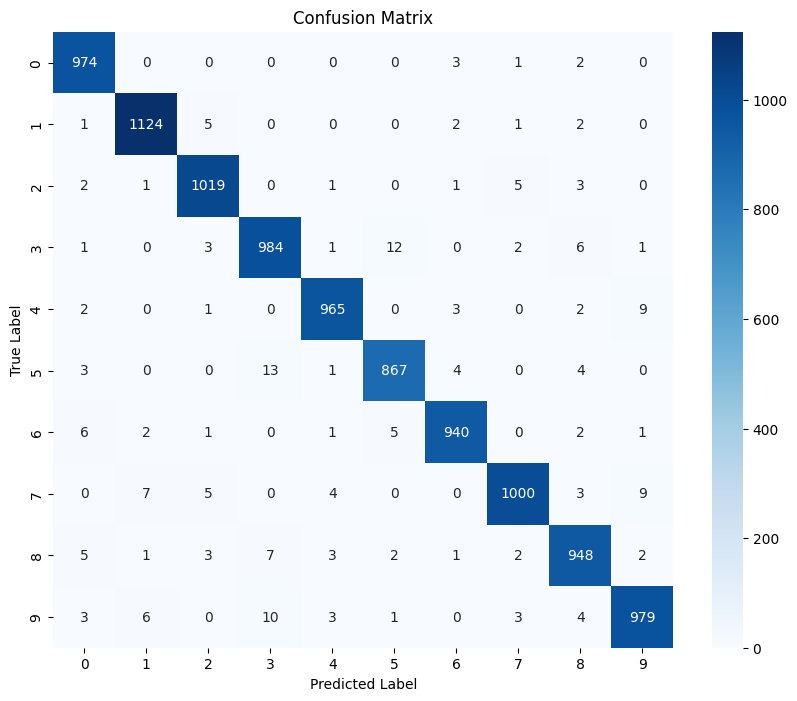

In [39]:
# 혼동 행렬 계산
conf_matrix = confusion_matrix(y_test, y_test_pred)

# 테스트 데이터 정확도 및 F1-Score 계산
test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1_score = f1_score(y_test, y_test_pred, average='weighted')

# 결과 출력
print(f"SVM Test Accuracy with HOG features: {test_accuracy * 100:.2f}%")
print(f"SVM Test F1 Score with HOG features: {test_f1_score:.2f}")

# 혼동 행렬 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()